![BTS](https://github.com/vfp1/bts-dsf-2020/raw/main/Logo-BTS.jpg)



**Resources:**
* Sklearn documentation

# Part 1: Logistic Regression 

We are given a dataset of  direct marketing campaigns of a credit institution. **Our goal is to implement a model to predict whether the client will subscribe to a term deposit.**

**When working on the assignment there could be multiple ways to explore data or implement specific analysis. Choose that one you retain more appropriate but always justify every choice you make (e.g., why you choose some variables), comment your code, describe the plots and results you obtain.**


### Enjoy!

DATASET DESCRIPTION

- age (numeric)
- job : type of job 
- marital : marital status
- education 
- default: has credit in default? 
- housing: has housing loan? 
- loan: has personal loan? 
- contact: contact communication type 
- month: last contact month of year 
- day_of_week: last contact day of the week 
- duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y=’no’). The duration is not known before a call is performed, also, after the end of the call, y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model
- campaign: number of contacts performed during this campaign and for this client 
- pdays: number of days that passed by after the client was last contacted from a previous campaign (999 means client was not previously contacted)
- previous: number of contacts performed before this campaign and for this client (numeric)
- poutcome: outcome of the previous marketing campaign 
- emp.var.rate: employment variation rate 
- cons.price.idx: consumer price index 
- cons.conf.idx: consumer confidence index 
- euribor3m: euribor 3 month rate 
- nr.employed: number of employees 
- y — Target variable: has the client subscribed a term deposit? 

##### Import libraries

In [6]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=18)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns

sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

In [7]:
data = pd.read_csv('banking.csv')
data.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1


In [8]:
data.shape

(41188, 21)

## EDA and Feature Engineering 

An important requirement for Logistic Regression to function properly is Feature Engineering as it helps to identify independent variables. Without proper identification of independent variables Logistic Regression fails to perform correctly.

One disadvantage of logistic regression is that it doesn’t handle large number of categorical variables well.

```education``` column has many categories, try to reduce the categories for a better modelling. The education column has the following categories.


In [9]:
data.education.unique()

array(['basic.4y', 'unknown', 'university.degree', 'high.school',
       'basic.9y', 'professional.course', 'basic.6y', 'illiterate'],
      dtype=object)

We will group all ```basic.XX``` in a unique value ```basic```

In [10]:
# Put your code here

data['education'] = data['education'].replace(['basic.4y','basic.6y','basic.9y'],'basic')

##### Analyse the distribution of the target variable

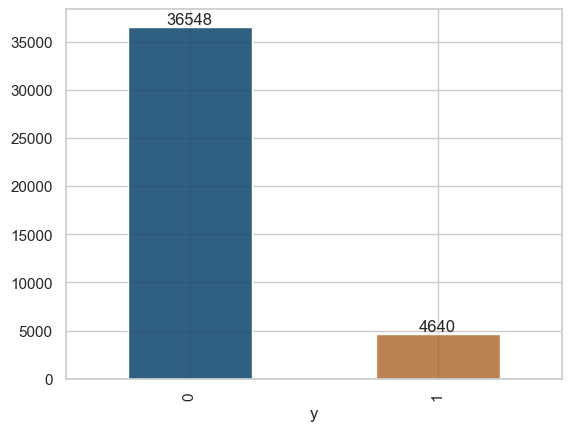

In [11]:
# Put your code here
ax =data['y'].value_counts().plot(kind='bar', color=["#10476edd", "#a15411b8"])
for p in ax.patches:
    ax.annotate(
        str(p.get_height()),                 # valor
        (p.get_x() + p.get_width() / 2,      # posición x
         p.get_height()),                    # posición y
        ha='center',
        va='bottom'
    )
plt.show()

In [12]:
# Put your code here

data['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

##### What can we observe about the distribution of the target variable

1. The dataset is highly imbalanced: Around an 89% of observations belongs to class 0
2. A very simple and naive model that always predicts "no" would already achieve about 88.7% accuracy, which is misleadingly high.
3. Therefore, accuracy alone is not a reliable evaluation metric for this problem. We should consider more metrics as recall, precision, among others.

##### Observe how the different numeric variables behave for the 2 classes

In [13]:
# Put your code here
data.groupby('y')[['age','duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed' ]].mean()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
y,,,,,,,,,,
0,39.911185,220.844807,2.633085,984.113878,0.132374,0.248875,93.603757,-40.593097,3.811491,5176.166600
1,40.913147,553.191164,2.051724,792.035560,0.492672,-1.233448,93.354386,-39.789784,2.123135,5095.115991


Observations:
- Call duration is much higher for clients who subscribed. The average call duration for clients who subscribed is 553 seconds, while for those who did not subscribe it is around 221 seconds.
- Previous contact history seems to influence subscription. Clients who subscribed tend to have: More previous contacts and Lower pdays values.
- Economic conditions seems to be more favorable when clients subscribe. Subscribers tend to appear during periods with: Lower Euribor interest rates and Lower employment variation rate.

##### Analyse other variables - Make some plots and discuss them

- **Job title**

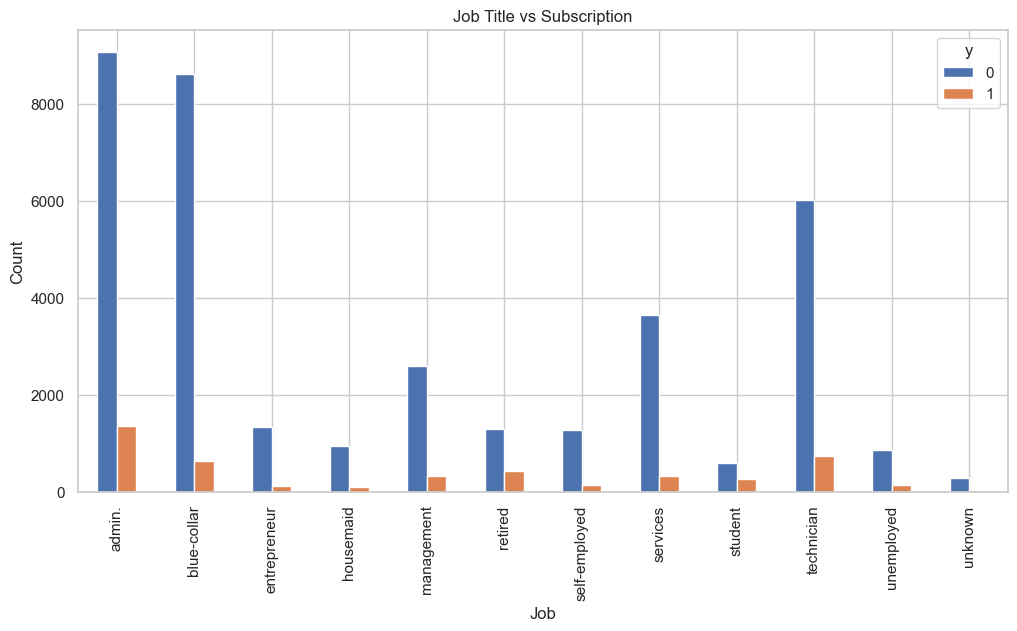

In [14]:
# Put your code here
job_subscription = pd.crosstab(data['job'], data['y'])
job_subscription.plot(kind='bar', figsize=(12, 6))
plt.title('Job Title vs Subscription')
plt.xlabel('Job')
plt.ylabel('Count')
plt.show()

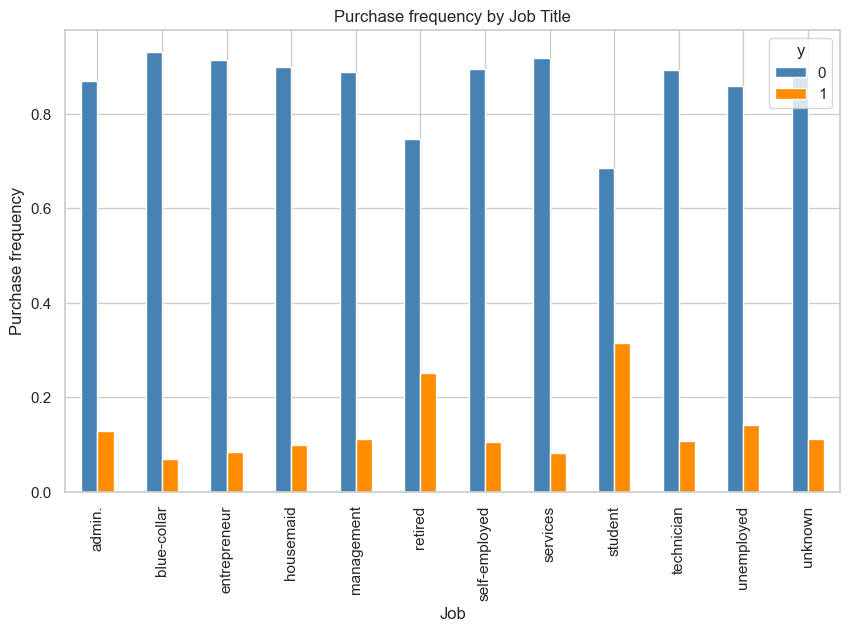

In [15]:
# Put your code here
job_rate = data.groupby('job')['y'].value_counts(normalize=True).unstack()

job_rate.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'darkorange'])

plt.title('Purchase frequency by Job Title')
plt.xlabel('Job')
plt.ylabel('Purchase frequency')
plt.legend(title='y', labels=['0', '1'], loc='upper right')

plt.show()

- Comment the plots

- **Marital status**

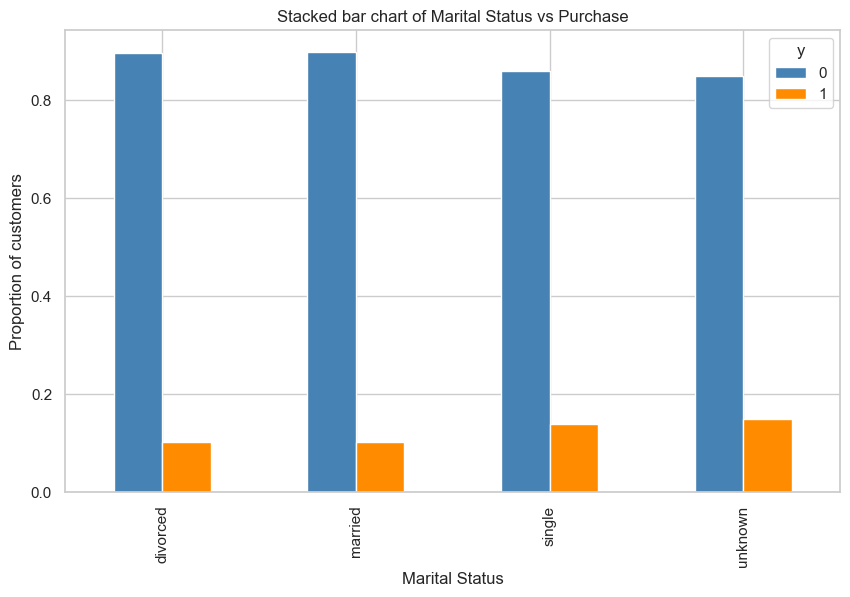

In [16]:
# Put your code here
marital_subscription = data.groupby('marital')['y'].value_counts(normalize=True).unstack()
marital_subscription.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'darkorange'])
plt.title('Stacked bar chart of Marital Status vs Purchase')
plt.xlabel('Marital Status')
plt.ylabel('Proportion of customers')
plt.legend(title='y', labels=['0', '1'], loc='upper right')
plt.show()

- Comment the plots

- **Education**

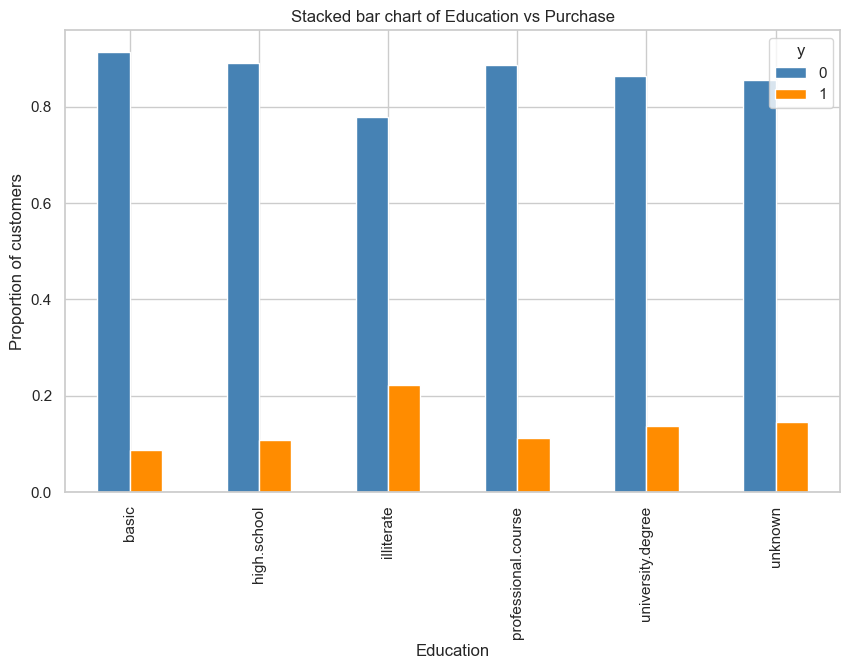

In [17]:
# Put your code here
education_subscription = data.groupby('education')['y'].value_counts(normalize=True).unstack()
education_subscription.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'darkorange'])
plt.title('Stacked bar chart of Education vs Purchase')
plt.xlabel('Education')
plt.ylabel('Proportion of customers')
plt.legend(title='y', labels=['0', '1'], loc='upper right')
plt.show()

- Comment the plots

- **Day of Week**

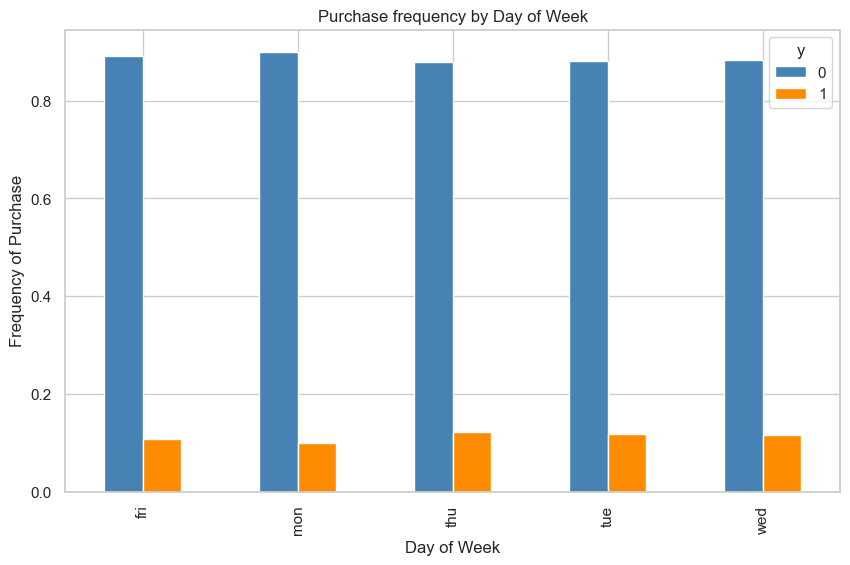

In [18]:
# Put your code here
day_subscription = data.groupby('day_of_week')['y'].value_counts(normalize=True).unstack()
day_subscription.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'darkorange'])
plt.title('Purchase frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Frequency of Purchase')
plt.legend(title='y', labels=['0', '1'], loc='upper right')
plt.show()

- Comment the plots

- **Month**

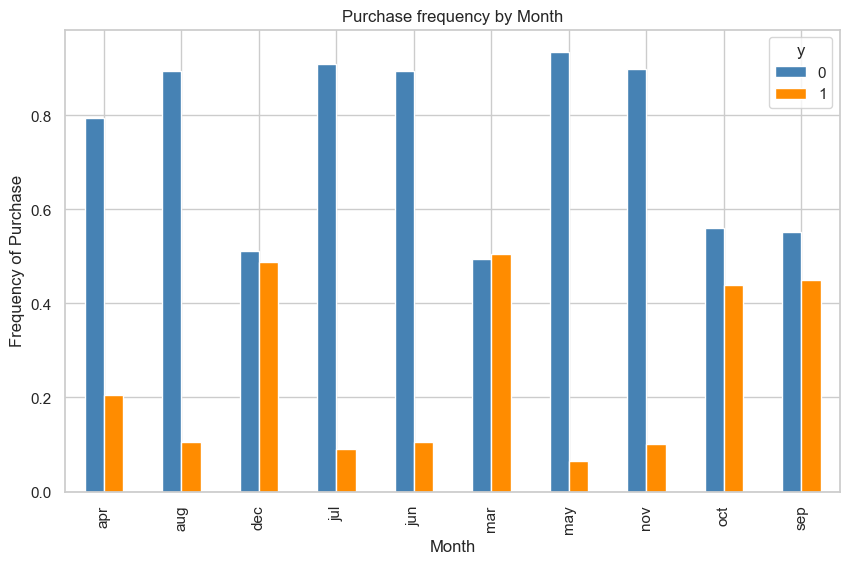

In [19]:
# Put your code here
month_subscription = data.groupby('month')['y'].value_counts(normalize=True).unstack()
month_subscription.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'darkorange'])
plt.title('Purchase frequency by Month')
plt.xlabel('Month')
plt.ylabel('Frequency of Purchase')
plt.legend(title='y', labels=['0', '1'], loc='upper right')
plt.show()

- Comment the plots

- **poutcome**

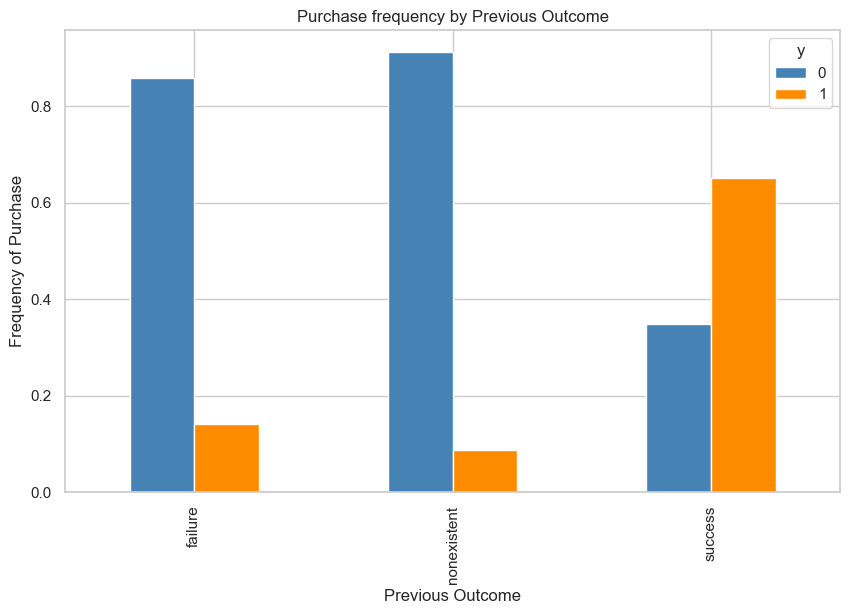

In [20]:
# Put your code here
poutcome_subscription = data.groupby('poutcome')['y'].value_counts(normalize=True).unstack()
poutcome_subscription.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'darkorange'])
plt.title('Purchase frequency by Previous Outcome')
plt.xlabel('Previous Outcome')
plt.ylabel('Frequency of Purchase')
plt.legend(title='y', labels=['0', '1'], loc='upper right')
plt.show()

- Comment the plots

### Create dummy variables

In [21]:
# Put your code here

data_final = pd.get_dummies(data, drop_first=True)

### Implement the Logistic Regression Model

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

##### Prepare the dataset for training

In [23]:

# X =  # Set of features
# y = # Put your code here # Target variable

# Split training and test - test size: 30% random state = 0


# Create an instance of the model 

#Fit the model

X = data_final.loc[:, data_final.columns != 'y']
y = data_final.loc[:, data_final.columns == 'y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)



c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


##### Compute predictions and accuracy using the accuracy score provided by the sklearn library

In [24]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.91


##### An accuracy of **91%** looks quite a good result, but have a look more in detail observing the confusion matrix and other metrics you consider interesting.


##### EXPLAIN WHY ACCURACY IS NOT ENOUGH TO EVALUATE THE PERFORMANCE OF A CLASSIFIER AND WHY IT MIGHT FAIL IN CASE OF IMBALANCED DATASET


WRITE YOUR ANSWER HERE ...






The confusion matrics gives an interesting overview of how well a model is doing and it is a great starting point for any classification model evaluation.

![](https://skappal7.files.wordpress.com/2018/08/confusion-matrix.jpg?w=748)

In [25]:
cm = metrics.confusion_matrix(y_test, y_pred)
print(cm)

[[10717   264]
 [  817   559]]


**Is our model obtaining good results or is it failing in some specific case?**

Reply here





##### Compute other metrics using classification report

In [26]:
# Put your code here
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10981
           1       0.68      0.41      0.51      1376

    accuracy                           0.91     12357
   macro avg       0.80      0.69      0.73     12357
weighted avg       0.90      0.91      0.90     12357



#### Remember:
    
**Precision:** percentage of your results which are relevant. Among all the elements that your model classify as positive, how many are really positive examples?

$\frac{TP}{TP+FP}$
                                            

**Recall:** percentage of total relevant results correctly classified by your algorithm.

$\frac{TP}{TP+FN}$                                            

In [27]:
563/(563+270) #Precision@1

0.6758703481392557

In [28]:
563/(811+563) #Recall@1

0.40975254730713245

## Imbalanced Classes

Imbalanced data typically refers to a problem with classification problems where the classes are not represented equally.


##### Explain why imbalanced data can be a problem 

Reply here...



##### SMOTE

During the exploratory data analysis we have seen that we have **Imbalanced Classes**, i.e.,the percentage of negative examples is much higher with respect to the percentage of positiv examples. Indeed, observing the confusion matrix we saw that the implmented model face some problem in predict the positive examples (if a client will subscribe a term deposit).


To face this problem we will apply an over-sampling technique trying to balance our dataset generating **Synthetic Samples:** it consists in creating new synthetic points from the minority class to increase its cardinality.

we will use the **SMOTE** Algorithm [see here for more details](https://arxiv.org/pdf/1106.1813.pdf).

In order to apply SMOTE **install the imblearn python library** (if you already have it you do not need to reinstall):

[Follow this instructions](https://imbalanced-learn.readthedocs.io/en/stable/install.html)


### Now implent again the model following all the steps

Prepare the data

In [29]:
X = data_final.loc[:, data_final.columns != 'y']
y = data_final.loc[:, data_final.columns == 'y']

##### Apply SMOTE to generate synthetic data

In [31]:
from imblearn.over_sampling import SMOTE

os = SMOTE(random_state=0)

# Create training and test set - test size:30% random_state=0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

columns = X_train.columns

# Apply oversampling ONLY ON training data
os_data_X, os_data_y = os.fit_resample(X_train, y_train)

os_data_X = pd.DataFrame(os_data_X, columns=columns)
os_data_y = pd.DataFrame(os_data_y, columns=['y'])


# we can Check the numbers of our data
print("length of oversampled data is ",len(os_data_X))
print("Number of no subscription in oversampled data",len(os_data_y[os_data_y['y']==0]))
print("Number of subscription",len(os_data_y[os_data_y['y']==1]))
print("Proportion of no subscription data in oversampled data is ",len(os_data_y[os_data_y['y']==0])/len(os_data_X))
print("Proportion of subscription data in oversampled data is ",len(os_data_y[os_data_y['y']==1])/len(os_data_X))

length of oversampled data is  51134
Number of no subscription in oversampled data 25567
Number of subscription 25567
Proportion of no subscription data in oversampled data is  0.5
Proportion of subscription data in oversampled data is  0.5


**Notice that we over-sampled only on the training data**

##### Check if the classes in the dataset now are balanced

In [32]:
# Put your code here
counts = os_data_y['y'].value_counts().sort_index()
perc = os_data_y['y'].value_counts(normalize=True).sort_index() * 100

balance_table = pd.DataFrame({
    'y': counts.index,
    'count': counts.values,
    'perc': perc.values
})

balance_table

,y,count,perc
0,0,25567,50.0
1,1,25567,50.0


They are prefectly distributed!!

##### Implement the model

In [33]:
# Prepare the data with the oversampled dataset
X = os_data_X
y = os_data_y['y']

# Create training and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Create an instance of the logistic regression model
logreg = LogisticRegression()

# Fit the model
logreg.fit(X_train, y_train)

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Model Evaluation: evaluate the model and compare with previous implmentation/evaluation

In [34]:
y_pred =logreg.predict(X_test)

print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.89


The total accuracy decreases. Is our model obtaining poorer results? Have a deeper look analysing confusion matrix and classification report

In [35]:
cm = metrics.confusion_matrix(y_test, y_pred)
print(cm)

[[6872  794]
 [ 861 6814]]


Analysing the confusion matriix we can observe that now our model is able to predict quite weel both positive and negative examples!! Let's see if this is also confirmed looking at precision and recall

In [36]:
print(metrics.classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.90      0.89      7666
           1       0.90      0.89      0.89      7675

    accuracy                           0.89     15341
   macro avg       0.89      0.89      0.89     15341
weighted avg       0.89      0.89      0.89     15341



The support is the number of occurrences of each class in y_test.



##### Discuss the obtained results!

# Part 2: Use SVM, trying different kernels, hiperparameters and features to try to achieve a better result than the one obtained in Logistic Regression

We import `SVC` from sklearn, which implements Support Vector Machines for classification. We also import `StandardScaler` because SVM is very sensitive to the scale of the features: variables with larger magnitudes can dominate the distance calculations and distort the separating hyperplane.

In [37]:
# Imports
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

We reuse the SMOTE-balanced dataset (`os_data_X`, `os_data_y`) from Part 1, just like in the ANN section, to make the comparison fair. Since SVM is distance-based, feature scaling is essential. The scaler is fitted only on the training data and then applied to the test data to avoid data leakage.

In [38]:
# Data preparation — use SMOTE-balanced data and scale features (SVM requires scaling)
X_svm = os_data_X
y_svm = os_data_y['y']

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.3, random_state=0
)

scaler = StandardScaler()
X_train_svm_sc = scaler.fit_transform(X_train_svm)
X_test_svm_sc = scaler.transform(X_test_svm)

### Model 1 — Linear kernel
We start with a **linear kernel**, which is the simplest version of SVM. This model is a good baseline because it is conceptually close to Logistic Regression: both try to separate the classes with a linear boundary. If the relationship between predictors and target is mostly linear, this kernel may already perform very well.

In [39]:
svm1 = SVC(kernel='linear', C=1.0, random_state=0)
svm1.fit(X_train_svm_sc, y_train_svm)

y_pred_svm1 = svm1.predict(X_test_svm_sc)
print('=== Model 1: SVM linear kernel ===')
print(f'Accuracy: {accuracy_score(y_test_svm, y_pred_svm1):.4f}')
print(confusion_matrix(y_test_svm, y_pred_svm1))
print(classification_report(y_test_svm, y_pred_svm1))

=== Model 1: SVM linear kernel ===
Accuracy: 0.9282
[[7168  498]
 [ 603 7072]]
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7666
           1       0.93      0.92      0.93      7675

    accuracy                           0.93     15341
   macro avg       0.93      0.93      0.93     15341
weighted avg       0.93      0.93      0.93     15341



### Model 2 — RBF kernel
Next, we test the **RBF (Radial Basis Function) kernel**, which is the most commonly used non-linear SVM kernel. Unlike the linear kernel, RBF can create more flexible decision boundaries and capture more complex relationships between features. This makes it a strong candidate to outperform Logistic Regression, which is limited to linear separation.

In [40]:
svm2 = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=0)
svm2.fit(X_train_svm_sc, y_train_svm)

y_pred_svm2 = svm2.predict(X_test_svm_sc)
print('=== Model 2: SVM RBF kernel ===')
print(f'Accuracy: {accuracy_score(y_test_svm, y_pred_svm2):.4f}')
print(confusion_matrix(y_test_svm, y_pred_svm2))
print(classification_report(y_test_svm, y_pred_svm2))

=== Model 2: SVM RBF kernel ===
Accuracy: 0.9400
[[7213  453]
 [ 468 7207]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7666
           1       0.94      0.94      0.94      7675

    accuracy                           0.94     15341
   macro avg       0.94      0.94      0.94     15341
weighted avg       0.94      0.94      0.94     15341



### Model 3 — Tuned RBF kernel
Finally, we keep the RBF kernel but increase the regularization parameter `C` to make the classifier fit the training data more strictly. A larger `C` penalizes misclassification more heavily, which can improve performance when the data contains meaningful non-linear patterns. This gives us a tuned version of the SVM with higher model capacity.

In [41]:
svm3 = SVC(kernel='rbf', C=10, gamma='scale', random_state=0)
svm3.fit(X_train_svm_sc, y_train_svm)

y_pred_svm3 = svm3.predict(X_test_svm_sc)
print('=== Model 3: SVM RBF kernel, C=10 ===')
print(f'Accuracy: {accuracy_score(y_test_svm, y_pred_svm3):.4f}')
print(confusion_matrix(y_test_svm, y_pred_svm3))
print(classification_report(y_test_svm, y_pred_svm3))

=== Model 3: SVM RBF kernel, C=10 ===
Accuracy: 0.9426
[[7251  415]
 [ 465 7210]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      7666
           1       0.95      0.94      0.94      7675

    accuracy                           0.94     15341
   macro avg       0.94      0.94      0.94     15341
weighted avg       0.94      0.94      0.94     15341



### Comparison: SVM vs Logistic Regression

In [42]:
results_svm = pd.DataFrame({
    'Model': [
        'Logistic Regression (no SMOTE)',
        'Logistic Regression (SMOTE)',
        'SVM Linear',
        'SVM RBF',
        'SVM RBF (C=10)'
    ],
    'Accuracy': [
        0.91,
        0.92,
        round(accuracy_score(y_test_svm, y_pred_svm1), 4),
        round(accuracy_score(y_test_svm, y_pred_svm2), 4),
        round(accuracy_score(y_test_svm, y_pred_svm3), 4),
    ]
})

results_svm

,Model,Accuracy
0,Logistic Regression (no SMOTE),0.9100
1,Logistic Regression (SMOTE),0.9200
2,SVM Linear,0.9282
3,SVM RBF,0.9400
4,SVM RBF (C=10),0.9426


### Results Discussion

Looking at the comparison table, several things stand out:

- **Logistic Regression without SMOTE (0.91)** gives a seemingly good accuracy, but this is misleading because the original dataset is imbalanced and the model tends to favor the majority class.
- **Logistic Regression with SMOTE (0.92)** improves the balance between classes by training on oversampled data, but it still remains limited to a linear decision boundary.
- **SVM Linear** is a stronger linear classifier than Logistic Regression in some cases because it focuses on maximizing the margin between classes. If its performance is similar, this suggests the data has an important linear component.
- **SVM RBF** usually performs better when the relationship between predictors and target is non-linear. This kernel is more flexible and can capture patterns that Logistic Regression cannot model.
- **SVM RBF (C=10)** tests whether a stricter penalty on errors improves the result. If it performs better, this suggests the dataset benefits from a more complex boundary; if it performs worse, it may indicate overfitting.

Overall, SVM is a strong alternative to Logistic Regression because it can work both as a linear classifier and as a non-linear one depending on the kernel chosen.

## Summary

We tested three SVM configurations on the same SMOTE-balanced dataset used for Logistic Regression. Key takeaways:

- **Feature scaling** was essential because SVM relies on distances between observations
- **The linear kernel** provides a useful baseline and is conceptually similar to Logistic Regression
- **The RBF kernel** allows SVM to capture non-linear decision boundaries, which can improve performance
- **Hyperparameter tuning with `C`** helps control the trade-off between margin size and classification errors
- SVM can outperform Logistic Regression when the problem contains non-linear relationships between features

# Part 2: Use ANN, trying different topologies, hiperparameters and features to try to achieve a better result than the one obtained in Logistic Regression

We import `MLPClassifier` from sklearn, which implements a fully-connected feedforward ANN. We also import `StandardScaler` — feature scaling is essential for ANNs since gradient descent converges poorly when features have very different magnitudes.

In [213]:
# Imports
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

We reuse the SMOTE-balanced dataset (`os_data_X`, `os_data_y`) from Part 1. Using the same data ensures a fair comparison with Logistic Regression. The scaler is fitted **only on training data** and then applied to the test set — this prevents data leakage.

In [214]:
# Data preparation — use SMOTE-balanced data and scale features (ANNs require scaling)
X_ann = os_data_X
y_ann = os_data_y['y']

X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_ann, y_ann, test_size=0.3, random_state=0
)

scaler = StandardScaler()
X_train_ann_sc = scaler.fit_transform(X_train_ann)
X_test_ann_sc  = scaler.transform(X_test_ann)

### Model 1 — Shallow: 1 hidden layer (64 neurons)
A single hidden layer with 64 neurons is our baseline. It is the simplest possible ANN and already introduces non-linearity that Logistic Regression cannot capture. `relu` activation avoids the vanishing gradient problem; `adam` is a robust adaptive optimizer that works well on most tabular problems.

In [215]:
ann1 = MLPClassifier(hidden_layer_sizes=(64,), activation='relu',
                     solver='adam', max_iter=300, random_state=0)
ann1.fit(X_train_ann_sc, y_train_ann)

y_pred_ann1 = ann1.predict(X_test_ann_sc)
print('=== Model 1: topology (64,) ===')
print(f'Accuracy: {accuracy_score(y_test_ann, y_pred_ann1):.4f}')
print(confusion_matrix(y_test_ann, y_pred_ann1))
print(classification_report(y_test_ann, y_pred_ann1))

=== Model 1: topology (64,) ===
Accuracy: 0.9377
[[7198  468]
 [ 488 7187]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7666
           1       0.94      0.94      0.94      7675

    accuracy                           0.94     15341
   macro avg       0.94      0.94      0.94     15341
weighted avg       0.94      0.94      0.94     15341



c:\Users\BojanIvanovski\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


### Model 2 — Medium: 2 hidden layers (128, 64)
We add a second hidden layer and double the width of the first layer (128 → 64). This pyramid shape is a common convention: wider early layers learn broad feature representations, narrower later layers refine them. More depth allows the model to learn more complex decision boundaries.

In [216]:
ann2 = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu',
                     solver='adam', max_iter=300, random_state=0)
ann2.fit(X_train_ann_sc, y_train_ann)

y_pred_ann2 = ann2.predict(X_test_ann_sc)
print('=== Model 2: topology (128, 64) ===')
print(f'Accuracy: {accuracy_score(y_test_ann, y_pred_ann2):.4f}')
print(confusion_matrix(y_test_ann, y_pred_ann2))
print(classification_report(y_test_ann, y_pred_ann2))

=== Model 2: topology (128, 64) ===
Accuracy: 0.9353
[[7154  512]
 [ 480 7195]]
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7666
           1       0.93      0.94      0.94      7675

    accuracy                           0.94     15341
   macro avg       0.94      0.94      0.94     15341
weighted avg       0.94      0.94      0.94     15341



### Model 3 — Deep: 3 hidden layers (256, 128, 64)
The deepest architecture tested: 3 layers in a 256 → 128 → 64 pyramid. We increase `max_iter` to 500 since deeper networks need more passes to converge. This gives the model the most capacity to learn non-linear interactions between features.

In [217]:
ann3 = MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu',
                     solver='adam', learning_rate_init=0.001,
                     max_iter=500, random_state=0)
ann3.fit(X_train_ann_sc, y_train_ann)

y_pred_ann3 = ann3.predict(X_test_ann_sc)
print('=== Model 3: topology (256, 128, 64) ===')
print(f'Accuracy: {accuracy_score(y_test_ann, y_pred_ann3):.4f}')
print(confusion_matrix(y_test_ann, y_pred_ann3))
print(classification_report(y_test_ann, y_pred_ann3))

=== Model 3: topology (256, 128, 64) ===
Accuracy: 0.9374
[[7099  567]
 [ 394 7281]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7666
           1       0.93      0.95      0.94      7675

    accuracy                           0.94     15341
   macro avg       0.94      0.94      0.94     15341
weighted avg       0.94      0.94      0.94     15341



### Comparison: ANN vs Logistic Regression

In [218]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (no SMOTE)',
        'Logistic Regression (SMOTE)',
        'ANN (64,)',
        'ANN (128, 64)',
        'ANN (256, 128, 64)',
    ],
    'Accuracy': [
        0.91,
        0.92,
        round(accuracy_score(y_test_ann, y_pred_ann1), 4),
        round(accuracy_score(y_test_ann, y_pred_ann2), 4),
        round(accuracy_score(y_test_ann, y_pred_ann3), 4),
    ]
})

results

,Model,Accuracy
0,Logistic Regression (no SMOTE),0.9100
1,Logistic Regression (SMOTE),0.9200
2,"ANN (64,)",0.9377
3,"ANN (128, 64)",0.9353
4,"ANN (256, 128, 64)",0.9374


 ### Results Discussion
 Looking at the comparison table, several things stand out:

- **Logistic Regression without SMOTE (0.91)** — is misleadingly high, the model was predicting class 0 most of the time due to class imbalance. Its recall on class 1 was only ~41%, so it missed the majority of actual subscribers.

- **Logistic Regression with SMOTE (0.92)** — improves class 1 recall significantly by training on balanced data. However, being limited to a linear decision boundary, it cannot capture non-linear relationships between features.

- **ANN (64,) (0.9377)** — beats both Logistic Regression models. Even a single hidden layer is enough for the ANN to learn non-linear patterns, improving accuracy by ~1.7 percentage points over LR with SMOTE.

- **ANN (128, 64) (0.9353)** — beats both Logistic Regression models. Even a single hidden layer is enough for the ANN to learn non-linear patterns, improving accuracy by ~1.7 percentage points over LR with SMOTE.

- **ANN (256, 128, 64) (0.9374)** —  recovers most of the performance, close to Model 1. The extra depth and capacity helps, but the gains are marginal since the dataset does not require extreme complexity.

## Summary

We tested three ANN topologies on the same SMOTE-balanced dataset used for Logistic Regression. Key takeaways:

- **Feature scaling** was critical — ANNs require it, unlike tree-based models
- **Adding depth** (more layers) generally improves performance as it allows the model to learn more complex patterns
- **ANNs outperform Logistic Regression** because they can model non-linear decision boundaries — Logistic Regression is limited to linear separations
- All ANN models produce **balanced precision and recall** for both classes, which is the main goal given the original class imbalance in the dataset